# Pipelines

## Preliminary analysis of data

Importing all necessary libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

Load dataset AvationData

In [11]:
data = pd.read_csv('AviationData.csv', encoding='ISO-8859-1', low_memory=False)
data['Event.Date'] = pd.to_datetime(data['Event.Date'], format="%Y-%m-%d")
data['Publication.Date'] = pd.to_datetime(data['Publication.Date'], format="%d-%m-%Y")

data.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaT
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,1996-09-19
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,2007-02-26
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,2000-09-12
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,1980-04-16


Basic EDA

In [12]:
print(data.info())
print(data.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Event.Id                88889 non-null  object        
 1   Investigation.Type      88889 non-null  object        
 2   Accident.Number         88889 non-null  object        
 3   Event.Date              88889 non-null  datetime64[ns]
 4   Location                88837 non-null  object        
 5   Country                 88663 non-null  object        
 6   Latitude                34382 non-null  object        
 7   Longitude               34373 non-null  object        
 8   Airport.Code            50132 non-null  object        
 9   Airport.Name            52704 non-null  object        
 10  Injury.Severity         87889 non-null  object        
 11  Aircraft.damage         85695 non-null  object        
 12  Aircraft.Category       32287 non-null  object

Select relevant columns

In [13]:
column_names = ["Event.Id", "Investigation.Type", "Accident.Number", "Event.Date" , "Location", "Country",
                "Latitude", "Longitude", "Airport.Code", "Airport.Name", "Injury.Severity", "Aircraft.damage",
                "Aircraft.Category", "Registration.Number" ,"Make", "Model", "Amateur.Built", "Number.of.Engines",
                "Engine.Type", "FAR.Description", "Schedule", "Purpose.of.flight", "Air.carrier", 
                "Total.Fatal.Injuries", "Total.Serious.Injuries", "Total.Minor.Injuries", "Total.Uninjured",
                "Weather.Condition", "Broad.phase.of.flight", "Report.Status", "Publication.Date"]

selected_cols = ["Investigation.Type", "Event.Date" , "Location", "Country",
                "Airport.Code", "Airport.Name", "Injury.Severity", "Aircraft.damage",
                "Make", "Model", "Amateur.Built", "Number.of.Engines",
                "Engine.Type", "Purpose.of.flight", 
                "Total.Fatal.Injuries", "Total.Serious.Injuries", "Total.Minor.Injuries", "Total.Uninjured",
                "Weather.Condition", "Broad.phase.of.flight", "Report.Status", "Publication.Date"]

data = data[selected_cols]

data.head()

,Investigation.Type,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Make,Model,...,Engine.Type,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,Accident,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,Fatal(2),Destroyed,Stinson,108-3,...,Reciprocating,Personal,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaT
1,Accident,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,Fatal(4),Destroyed,Piper,PA24-180,...,Reciprocating,Personal,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,1996-09-19
2,Accident,1974-08-30,"Saltville, VA",United States,NaN,NaN,Fatal(3),Destroyed,Cessna,172M,...,Reciprocating,Personal,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,2007-02-26
3,Accident,1977-06-19,"EUREKA, CA",United States,NaN,NaN,Fatal(2),Destroyed,Rockwell,112,...,Reciprocating,Personal,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,2000-09-12
4,Accident,1979-08-02,"Canton, OH",United States,NaN,NaN,Fatal(1),Destroyed,Cessna,501,...,NaN,Personal,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,1980-04-16


Missing values in each column

In [14]:
print("Missing values per column:", data.isnull().sum(), sep="\n")

Missing values per column:
Investigation.Type            0
Event.Date                    0
Location                     52
Country                     226
Airport.Code              38757
Airport.Name              36185
Injury.Severity            1000
Aircraft.damage            3194
Make                         63
Model                        92
Amateur.Built               102
Number.of.Engines          6084
Engine.Type                7096
Purpose.of.flight          6192
Total.Fatal.Injuries      11401
Total.Serious.Injuries    12510
Total.Minor.Injuries      11933
Total.Uninjured            5912
Weather.Condition          4492
Broad.phase.of.flight     27165
Report.Status              6384
Publication.Date          13771
dtype: int64


Separating features and target

In [15]:
X = data.drop("Investigation.Type", axis=1)
y = data["Investigation.Type"].map({'Accident': 1, 'Incident': 0})

Identification of caetgorical and numerical columns

In [16]:
cols_numerical = X.select_dtypes(include=['int64', 'float64']).columns
cols_categorical = X.select_dtypes(include=['object', 'category']).columns

Creating preprocessing pipelines

In [17]:
transformer_numerical = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
transformer_categorical = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', transformer_numerical, cols_numerical),
        ('categorical', transformer_categorical, cols_categorical)
    ])

Defining the Pipeline Model

In [55]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

Splitting data into training and testing sets

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training the model

In [19]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Number.of.Engines', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Location', 'Country', 'Airport.Code', 'Airport.Name',
       'Injury.Severity', 'Aircraft.damage', 'Make', 'Model', 'Amateur.Built',
       'Engine.Type', 'Purpose.of.flight', 'Weather.Condition',
       'Broad.phase.of.flight', 'Report.Status'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

Evaluating the model

In [20]:
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9918438519518507
Classification Report:
               precision    recall  f1-score   support

    Accident       0.99      1.00      1.00     16958
    Incident       0.96      0.86      0.91       820

    accuracy                           0.99     17778
   macro avg       0.98      0.93      0.95     17778
weighted avg       0.99      0.99      0.99     17778



## Finding the best models and transformations

In [54]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, Normalizer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.svm import SVC
from sklearn.tree import ExtraTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import time
from sklearn.base import clone

In [ ]:
# for numerical columns
scalers = [
    ('StandardScaler', Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())])),
    ('MinMaxScaler', Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', MinMaxScaler())])),
    ('Normalizer', Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', Normalizer())]))
]

# for categorical columns
cat_transformers = [
    ('OrdinalEncoder', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder())])),
    ('OneHotEncoder', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]))
]

In [55]:
classifier_classes = [
    lambda: CatBoostClassifier(silent=True, iterations=500),
    XGBClassifier,
    lambda: LGBMClassifier(verbose=-1),
    DummyClassifier,
    LogisticRegression,
    lambda: KNeighborsClassifier(n_neighbors=2),
    ExtraTreeClassifier,
    RandomForestClassifier,
    SVC
]

Preparing a pipeline

In [36]:
pipe = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', None)
])

In [59]:
pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'classifier', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__numerical', 'preprocessor__categorical', 'preprocessor__numerical__memory', 'preprocessor__numerical__steps', 'preprocessor__numerical__transform_input', 'preprocessor__numerical__verbose', 'preprocessor__numerical__imputer', 'preprocessor__numerical__scaler', 'preprocessor__numerical__imputer__add_indicator', 'preprocessor__numerical__imputer__copy', 'preprocessor__numerical__imputer__fill_value', 'preprocessor__numerical__imputer__keep_empty_features', 'preprocessor__numerical__imputer__missing_values', 'preprocessor__numerical__imputer__strategy', 'preprocessor__numerical__scaler__copy', 'preprocessor__numerical__scaler__w

Place for storing results

In [52]:
results = []
models_df = None

In [51]:
def make_pipeline(scaler, encoder, model):
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', scaler)
    ])
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', encoder)
    ])
    preprocessor = ColumnTransformer([
        ('numerical', num_pipeline, cols_numerical),
        ('categorical', cat_pipeline, cols_categorical)
    ])
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

Checking all the models and columns' transformators

In [56]:
for clf_class in classifier_classes:
    for num_tr_name, num_tr in scalers:
        for cat_tr_name, cat_tr in cat_transformers:
            model = clf_class() if callable(clf_class) else clone(clf_class)
            print(f"DEBUG: {num_tr_name}, {cat_tr_name}, {model.__class__.__name__}")
            pipe = make_pipeline(num_tr, cat_tr, model)

            start_time = time.time()
            pipe.fit(X_train, y_train)   
            end_time = time.time()

            score = pipe.score(X_test, y_test)

            param_dict = {
                        'model': model.__class__.__name__,
                        'num_trans': num_tr_name,
                        'cat_trans': cat_tr_name,
                        'score': score,
                        'time_elapsed': end_time - start_time
            }

            print(param_dict)
            results.append(param_dict)
            pd.DataFrame(results).to_csv('models.csv', index=True)
 
models_df = pd.DataFrame(results)
models_df.to_csv('all_models.csv', index=True)

DEBUG: StandardScaler, OrdinalEncoder, CatBoostClassifier
{'model': 'CatBoostClassifier', 'num_trans': 'StandardScaler', 'cat_trans': 'OrdinalEncoder', 'score': 0.9918438519518507, 'time_elapsed': 7.141818046569824}
DEBUG: StandardScaler, OneHotEncoder, CatBoostClassifier
{'model': 'CatBoostClassifier', 'num_trans': 'StandardScaler', 'cat_trans': 'OneHotEncoder', 'score': 0.9926875914051074, 'time_elapsed': 105.51834535598755}
DEBUG: MinMaxScaler, OrdinalEncoder, CatBoostClassifier
{'model': 'CatBoostClassifier', 'num_trans': 'MinMaxScaler', 'cat_trans': 'OrdinalEncoder', 'score': 0.9918438519518507, 'time_elapsed': 12.506924629211426}
DEBUG: MinMaxScaler, OneHotEncoder, CatBoostClassifier
{'model': 'CatBoostClassifier', 'num_trans': 'MinMaxScaler', 'cat_trans': 'OneHotEncoder', 'score': 0.9926313421082237, 'time_elapsed': 106.28148603439331}
DEBUG: Normalizer, OrdinalEncoder, CatBoostClassifier
{'model': 'CatBoostClassifier', 'num_trans': 'Normalizer', 'cat_trans': 'OrdinalEncoder', '

c:\Users\maja\anaconda3\envs\clean_pipeline\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'model': 'LogisticRegression', 'num_trans': 'StandardScaler', 'cat_trans': 'OrdinalEncoder', 'score': 0.9517381032737091, 'time_elapsed': 1.3711144924163818}
DEBUG: StandardScaler, OneHotEncoder, LogisticRegression


c:\Users\maja\anaconda3\envs\clean_pipeline\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'model': 'LogisticRegression', 'num_trans': 'StandardScaler', 'cat_trans': 'OneHotEncoder', 'score': 0.9921250984362695, 'time_elapsed': 2.442469358444214}
DEBUG: MinMaxScaler, OrdinalEncoder, LogisticRegression


...

{'model': 'LogisticRegression', 'num_trans': 'MinMaxScaler', 'cat_trans': 'OneHotEncoder', 'score': 0.9917876026549668, 'time_elapsed': 2.4158599376678467}
DEBUG: Normalizer, OrdinalEncoder, LogisticRegression


c:\Users\maja\anaconda3\envs\clean_pipeline\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'model': 'LogisticRegression', 'num_trans': 'Normalizer', 'cat_trans': 'OrdinalEncoder', 'score': 0.9528630892113849, 'time_elapsed': 1.3416712284088135}
DEBUG: Normalizer, OneHotEncoder, LogisticRegression


c:\Users\maja\anaconda3\envs\clean_pipeline\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'model': 'LogisticRegression', 'num_trans': 'Normalizer', 'cat_trans': 'OneHotEncoder', 'score': 0.9919001012487344, 'time_elapsed': 2.244076728820801}
DEBUG: StandardScaler, OrdinalEncoder, KNeighborsClassifier
{'model': 'KNeighborsClassifier', 'num_trans': 'StandardScaler', 'cat_trans': 'OrdinalEncoder', 'score': 0.9077511531105861, 'time_elapsed': 0.8486764430999756}
DEBUG: StandardScaler, OneHotEncoder, KNeighborsClassifier
{'model': 'KNeighborsClassifier', 'num_trans': 'StandardScaler', 'cat_trans': 'OneHotEncoder', 'score': 0.9832939588255147, 'time_elapsed': 0.7593076229095459}
DEBUG: MinMaxScaler, OrdinalEncoder, KNeighborsClassifier
{'model': 'KNeighborsClassifier', 'num_trans': 'MinMaxScaler', 'cat_trans': 'OrdinalEncoder', 'score': 0.9078636517043537, 'time_elapsed': 0.7342982292175293}
DEBUG: MinMaxScaler, OneHotEncoder, KNeighborsClassifier
{'model': 'KNeighborsClassifier', 'num_trans': 'MinMaxScaler', 'cat_trans': 'OneHotEncoder', 'score': 0.9840814489818878, 'time_elaps

In [57]:
models_df.sort_values('score', ascending=False)

,model,num_trans,cat_trans,score,time_elapsed
15,LGBMClassifier,MinMaxScaler,OneHotEncoder,0.993588,2.104457
17,LGBMClassifier,Normalizer,OneHotEncoder,0.993363,2.041907
13,LGBMClassifier,StandardScaler,OneHotEncoder,0.993306,2.258587
7,XGBClassifier,StandardScaler,OneHotEncoder,0.993306,5.502697
9,XGBClassifier,MinMaxScaler,OneHotEncoder,0.993194,4.338562
11,XGBClassifier,Normalizer,OneHotEncoder,0.992969,3.269264
45,RandomForestClassifier,MinMaxScaler,OneHotEncoder,0.992744,312.483595
47,RandomForestClassifier,Normalizer,OneHotEncoder,0.992744,291.556244
1,CatBoostClassifier,StandardScaler,OneHotEncoder,0.992688,105.518345
3,CatBoostClassifier,MinMaxScaler,OneHotEncoder,0.992631,106.281486


In [58]:
models_df[['model', 'score', 'time_elapsed']] \
    .groupby('model') \
    .aggregate({
        'score': ['mean','std', 'min', 'max'],
        'time_elapsed': ['mean','std', 'min', 'max']
        }) \
    .reset_index() \
    .sort_values(('score', 'mean'), ascending=False)

model     score                                \
                               mean       std       min       max   
4          LGBMClassifier  0.992884  0.000606  0.992238  0.993588   
8           XGBClassifier  0.992556  0.000669  0.991844  0.993306   
0      CatBoostClassifier  0.992256  0.000399  0.991844  0.992688   
6  RandomForestClassifier  0.992059  0.000603  0.991450  0.992744   
2     ExtraTreeClassifier  0.980650  0.003375  0.976994  0.985206   
7                     SVC  0.972888  0.020827  0.953876  0.992013   
5      LogisticRegression  0.971997  0.021848  0.951569  0.992125   
1         DummyClassifier  0.953876  0.000000  0.953876  0.953876   
3    KNeighborsClassifier  0.945944  0.041759  0.907751  0.984813   

  time_elapsed                                     
          mean         std        min         max  
4     1.842639    0.334411   1.466576    2.258587  
8     2.857411    1.802821   1.260150    5.502697  
0    57.366506   51.800941   7.141818  106.281486  
6   159.033709  161.838192  11.234484  315.691437  
2     2.964546    2.363648   0.765559    5.561518  
7    40.993103   10.261178  30.903932   55.473508  
5     1.868209    0.551386   1.341671    2.442469  
1     0.830449    0.055441   0.776868    0.913220  
3     0.816962    0.079440   0.734298    0.944590

<Axes: xlabel='score', ylabel='model'>

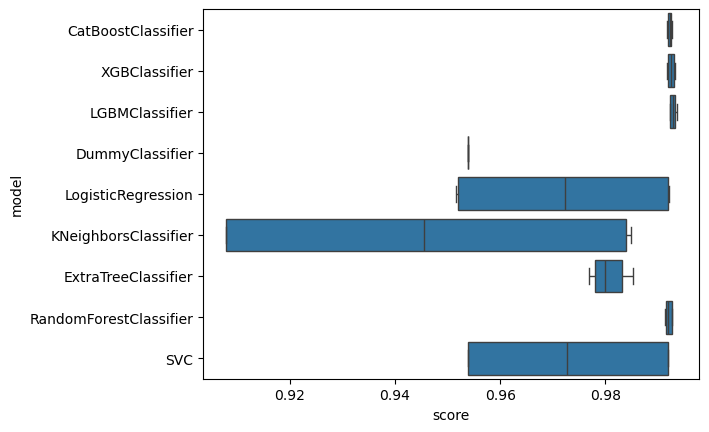

In [59]:
sns.boxplot(data=models_df, x='score', y='model')

<Axes: xlabel='score', ylabel='num_trans'>

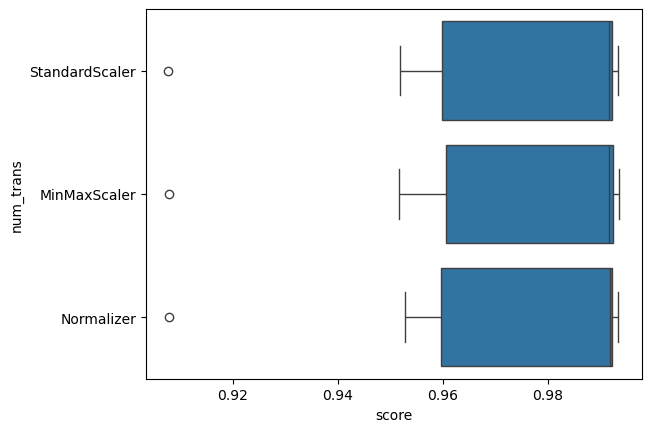

In [60]:
	
sns.boxplot(data=models_df, x='score', y='num_trans')

<Axes: xlabel='score', ylabel='cat_trans'>

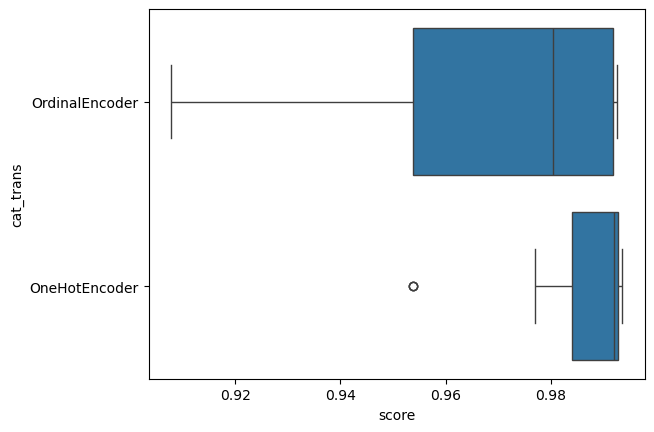

In [61]:
	
sns.boxplot(data=models_df, x='score', y='cat_trans')

<Axes: xlabel='time_elapsed', ylabel='model'>

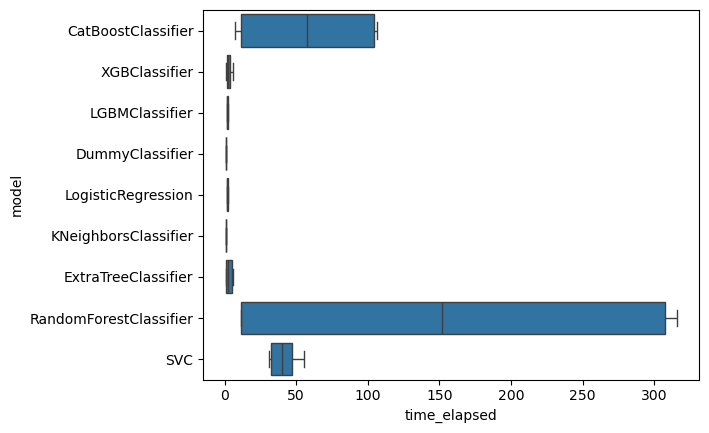

In [62]:
sns.boxplot(data=models_df, x='time_elapsed', y='model')